#K-Fold Cross-Validation

**The Goal:** To prove our model isn't just "lucky." Instead of one test, we split the data into 5 chunks (Folds), and the model has to prove itself 5 different times.

#Imports and Data Setup

In [1]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

# 1. Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Define the Model we want to test
# We'll use Random Forest, but this works for XGBoost or SVM too!
model = RandomForestClassifier(n_estimators=100, random_state=42)

#Running the 5-Fold Cross-Validation

In [2]:
# 3. Apply K-Fold
# cv=5 means the data is split into 5 parts. 
# The model trains on 4 parts and tests on 1, repeating this 5 times.
scores = cross_val_score(model, X, y, cv=5)

print("-" * 30)
print(f"Scores for each fold: {scores}")
print(f"Average Accuracy: {np.mean(scores)*100:.2f}%")
print(f"Stability (Std Dev): {np.std(scores):.4f}")
print("-" * 30)

------------------------------
Scores for each fold: [0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
Average Accuracy: 95.61%
Stability (Std Dev): 0.0228
------------------------------


#Visualizing the Consistency

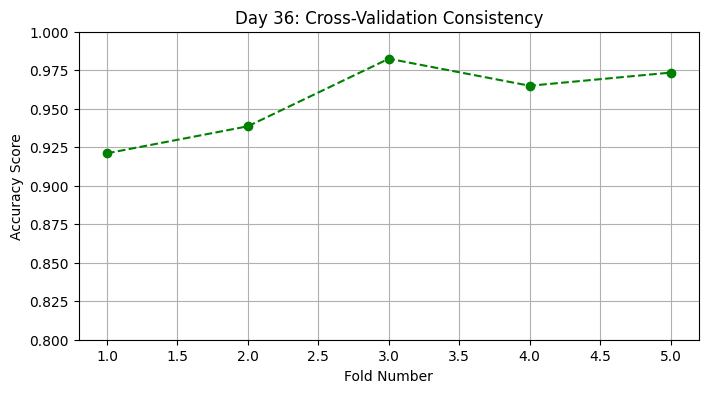

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), scores, marker='o', linestyle='--', color='green')
plt.title("Day 36: Cross-Validation Consistency")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy Score")
plt.ylim(0.8, 1.0)
plt.grid(True)
plt.savefig('../assets/day36_plot.png')
plt.show()